In [17]:
!ls /home/jupyter/app/output/b10_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f5_perceptual_100_f6_l1_loss_100/media/logs/video_metrics.csv

/home/jupyter/app/output/b10_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f5_perceptual_100_f6_l1_loss_100/media/logs/video_metrics.csv


In [18]:
import pandas as pd

In [19]:
path = "/home/jupyter/app/output/b10_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f5_perceptual_100_f6_l1_loss_100/media/logs/video_metrics.csv"
df = pd.read_csv(path, index_col=0)

In [20]:
df = df.set_index("path_id")

In [21]:
df

,SSIM,PSNR,MSE,L1,ACD
path_id,,,,,
001_surprise_take000,0.907424,35.552080,0.001080,0.018089,0.000167
001_disgust_take004,0.888442,33.491116,0.001869,0.022296,0.000935
001_surprise_take002,0.908098,35.419254,0.001112,0.018636,0.000035
001_happiness_take002,0.913386,35.732044,0.001032,0.017907,NaN
001_happiness_take000,0.899586,34.423157,0.001405,0.020708,0.000149
...,...,...,...,...,...
020_anger_take003,0.878234,30.430098,0.003517,0.040359,0.000694
020_surprise_take002,0.875298,30.717953,0.003303,0.036975,0.000552
020_disgust_take000,0.902274,31.273106,0.002851,0.036452,NaN


In [22]:

df_normalized = df.copy()
df_normalized['SSIM'] = df_normalized['SSIM'] /df_normalized['SSIM'].abs().max()
df_normalized['PSNR'] = df_normalized['PSNR'] /df_normalized['PSNR'].abs().max()
df_normalized['MSE'] = 1 - df_normalized['MSE'] /df_normalized['MSE'].abs().max()
df_normalized['L1'] = 1 - df_normalized['L1'] /df_normalized['L1'].abs().max()
df_normalized['ACD'] = 1 - df_normalized['ACD'] /df_normalized['ACD'].abs().max()


In [23]:
df_normalized

,SSIM,PSNR,MSE,L1,ACD
path_id,,,,,
001_surprise_take000,0.956933,0.979755,0.797614,0.605383,0.944332
001_disgust_take004,0.936916,0.922959,0.649829,0.513590,0.689027
001_surprise_take002,0.957644,0.976095,0.791775,0.593437,0.988227
001_happiness_take002,0.963221,0.984715,0.806717,0.609341,NaN
001_happiness_take000,0.948668,0.948644,0.736887,0.548235,0.950465
...,...,...,...,...,...
020_anger_take003,0.926151,0.838602,0.341286,0.119551,0.769127
020_surprise_take002,0.923055,0.846535,0.381349,0.193371,0.816542
020_disgust_take000,0.951502,0.861834,0.465918,0.204784,NaN


In [24]:
mean_measures = df_normalized.mean(axis=1)
mean_measures

path_id
001_surprise_take000     0.856803
001_disgust_take004      0.742464
001_surprise_take002     0.861436
001_happiness_take002    0.840999
001_happiness_take000    0.826580
                           ...   
020_anger_take003        0.598943
020_surprise_take002     0.632170
020_disgust_take000      0.621010
020_surprise_take001     0.679379
020_surprise_take000     0.555301
Length: 92, dtype: float64

In [25]:
sorted_mean_measures = mean_measures.sort_values(ascending=False)
sorted_mean_measures

path_id
001_surprise_take002            0.861436
001_anger_take003               0.858874
002_session0_sadness_take006    0.858671
001_fear_take002nsg             0.858594
001_surprise_take000            0.856803
                                  ...   
020_anger_take000               0.555011
020_mixed_take000               0.548313
020_disgust_take002             0.532030
020_happiness_take000           0.524767
020_fear_take000                0.496404
Length: 92, dtype: float64

In [26]:
sorted_mean_measures.to_csv("/home/jupyter/app/output/b10_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f5_perceptual_100_f6_l1_loss_100/media/logs/sorted_mean_measures.csv")

<Axes: xlabel='path_id'>

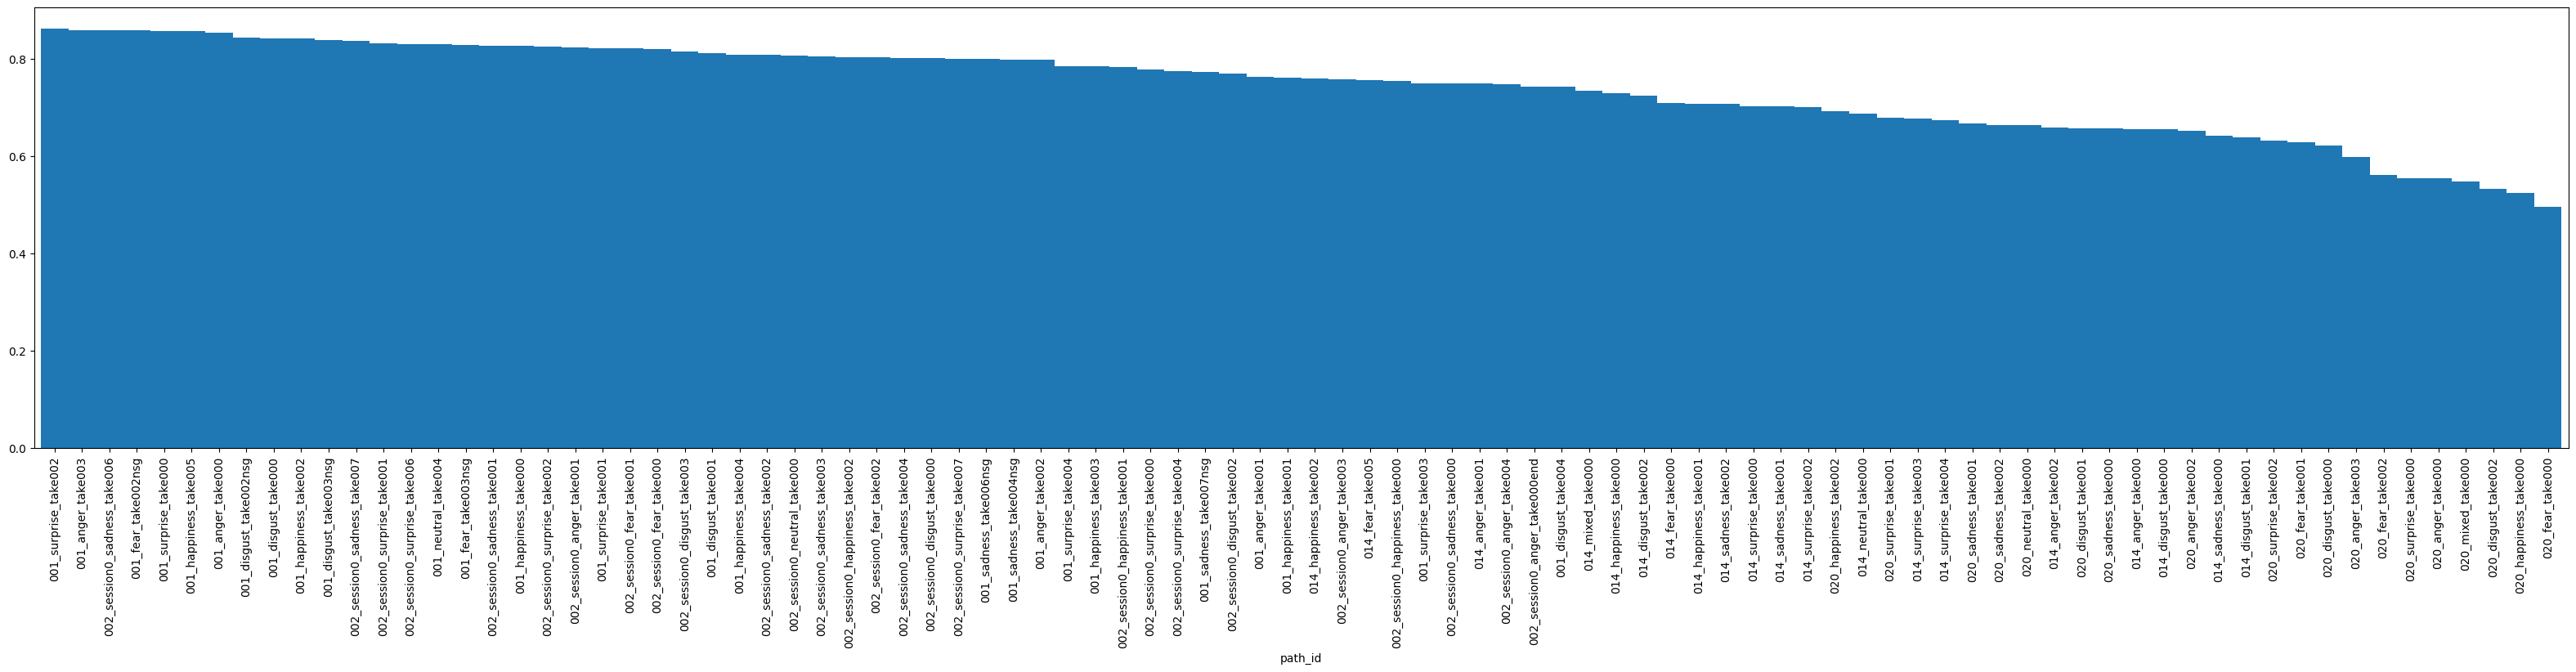

In [27]:
sorted_mean_measures.plot.bar(figsize=(40,7), width=1.0)